# Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np

## Creates distributions

In [2]:
def create_dist_synth(n_sample=1000, seed=0):
    """
    Create synthetic samples from several probability distributions.
    Returns a dictionary: {distribution_name: values}.
    """
    if n_sample <= 0:
        raise ValueError("n_sample must be positive.")

    rng = np.random.default_rng(seed)

    distributions = {
        "Uniform": rng.uniform(0, 1, n_sample),
        "Normal": rng.normal(0, 1, n_sample),
        "Exponential": rng.exponential(1, n_sample),
        "Poisson": rng.poisson(3, n_sample),
        "Binomial": rng.binomial(10, 0.3, n_sample),
        "Geometric": rng.geometric(0.2, n_sample),
        "Logistic": rng.logistic(0, 1, n_sample),
        "Chi-Square": rng.chisquare(5, n_sample),
        "Beta": rng.beta(2, 5, n_sample),
        "Gamma": rng.gamma(2, 1, n_sample),
        "Cauchy": rng.standard_cauchy(n_sample),
        "Laplace": rng.laplace(0, 1, n_sample),
        "Weibull": rng.weibull(2, n_sample),
        "Rayleigh": rng.rayleigh(1, n_sample),
        "Pareto": rng.pareto(2, n_sample),
        "F": rng.f(2, 5, n_sample),
        "Exponential scale=2": rng.exponential(2, n_sample),
        "Hypergeometric": rng.hypergeometric(10, 5, 7, n_sample),
        "Wald": rng.wald(2, 3, n_sample),
        "Zipf": rng.zipf(2, n_sample),
        "Triangular": rng.triangular(0, 0.5, 1, n_sample),
    }

    return distributions




## Plots graphic of all distributions

In [3]:
def plot_graph_distr(distributions, n_cols=4, bins=30, figsize_per_plot=(4.5, 3.5),
                     trim_heavy_tails=True):
    """
    Plot histograms for a dictionary of distributions.
    """
    if n_cols <= 0:
        raise ValueError("n_cols must be positive.")

    num_graphs = len(distributions)
    num_rows = int(np.ceil(num_graphs / n_cols))

    fig_width = figsize_per_plot[0] * n_cols
    fig_height = figsize_per_plot[1] * num_rows

    fig, axes = plt.subplots(
        num_rows,
        n_cols,
        figsize=(fig_width, fig_height),
        squeeze=False
    )

    axes = axes.flatten()

    fig.suptitle("Various Probability Distributions", fontsize=16)

    for i, (name, values) in enumerate(distributions.items()):
        ax = axes[i]

        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if trim_heavy_tails and len(values) > 0:
            q_low, q_high = np.quantile(values, [0.01, 0.99])
            values = values[(values >= q_low) & (values <= q_high)]

        ax.hist(values, bins=bins, alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    for j in range(num_graphs, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    return fig

## Plot single distribution

In [4]:
def plot_single_distribution(
    distributions,
    name,
    bins=30,
    figsize=(7, 4),
    density=False,
    trim_heavy_tails=True,
    quantile_range=(0.01, 0.99),
    discrete="auto",
    color=None,
    save_path=None,
    show=True
):
    """
    Plot a single probability distribution from a dictionary.

    Parameters
    ----------
    distributions : dict
        Dictionary in the form {distribution_name: values}.

    name : str
        Name of the distribution to plot.

    bins : int
        Number of bins for continuous histograms.

    figsize : tuple
        Figure size.

    density : bool
        If True, normalizes the histogram/bar plot.

    trim_heavy_tails : bool
        If True, removes extreme values using quantiles.

    quantile_range : tuple
        Lower and upper quantiles used for trimming.

    discrete : bool or "auto"
        If "auto", tries to infer whether the distribution is discrete.

    color : str or None
        Optional matplotlib color.

    save_path : str or None
        If provided, saves the figure to this path.

    show : bool
        If True, displays the plot.

    Returns
    -------
    fig, ax
        Matplotlib figure and axis.
    """

    if name not in distributions:
        available = ", ".join(distributions.keys())
        raise KeyError(f"Distribution '{name}' not found. Available: {available}")

    values = np.asarray(distributions[name], dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        raise ValueError(f"Distribution '{name}' has no finite values.")

    if trim_heavy_tails:
        q_low, q_high = np.quantile(values, quantile_range)
        values = values[(values >= q_low) & (values <= q_high)]

    if len(values) == 0:
        raise ValueError(f"After trimming, distribution '{name}' has no values.")

    if discrete == "auto":
        is_discrete = np.allclose(values, np.round(values)) and len(np.unique(values)) <= 100
    else:
        is_discrete = bool(discrete)

    fig, ax = plt.subplots(figsize=figsize)

    if is_discrete:
        x, counts = np.unique(values.astype(int), return_counts=True)

        if density:
            y = counts / counts.sum()
            ylabel = "Probability"
        else:
            y = counts
            ylabel = "Frequency"

        ax.bar(x, y, alpha=0.75, color=color)
        ax.set_xticks(x)

    else:
        ax.hist(values, bins=bins, density=density, alpha=0.75, color=color)
        ylabel = "Density" if density else "Frequency"

    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

    fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

# Statistical Distributions

## Plots of all distributions

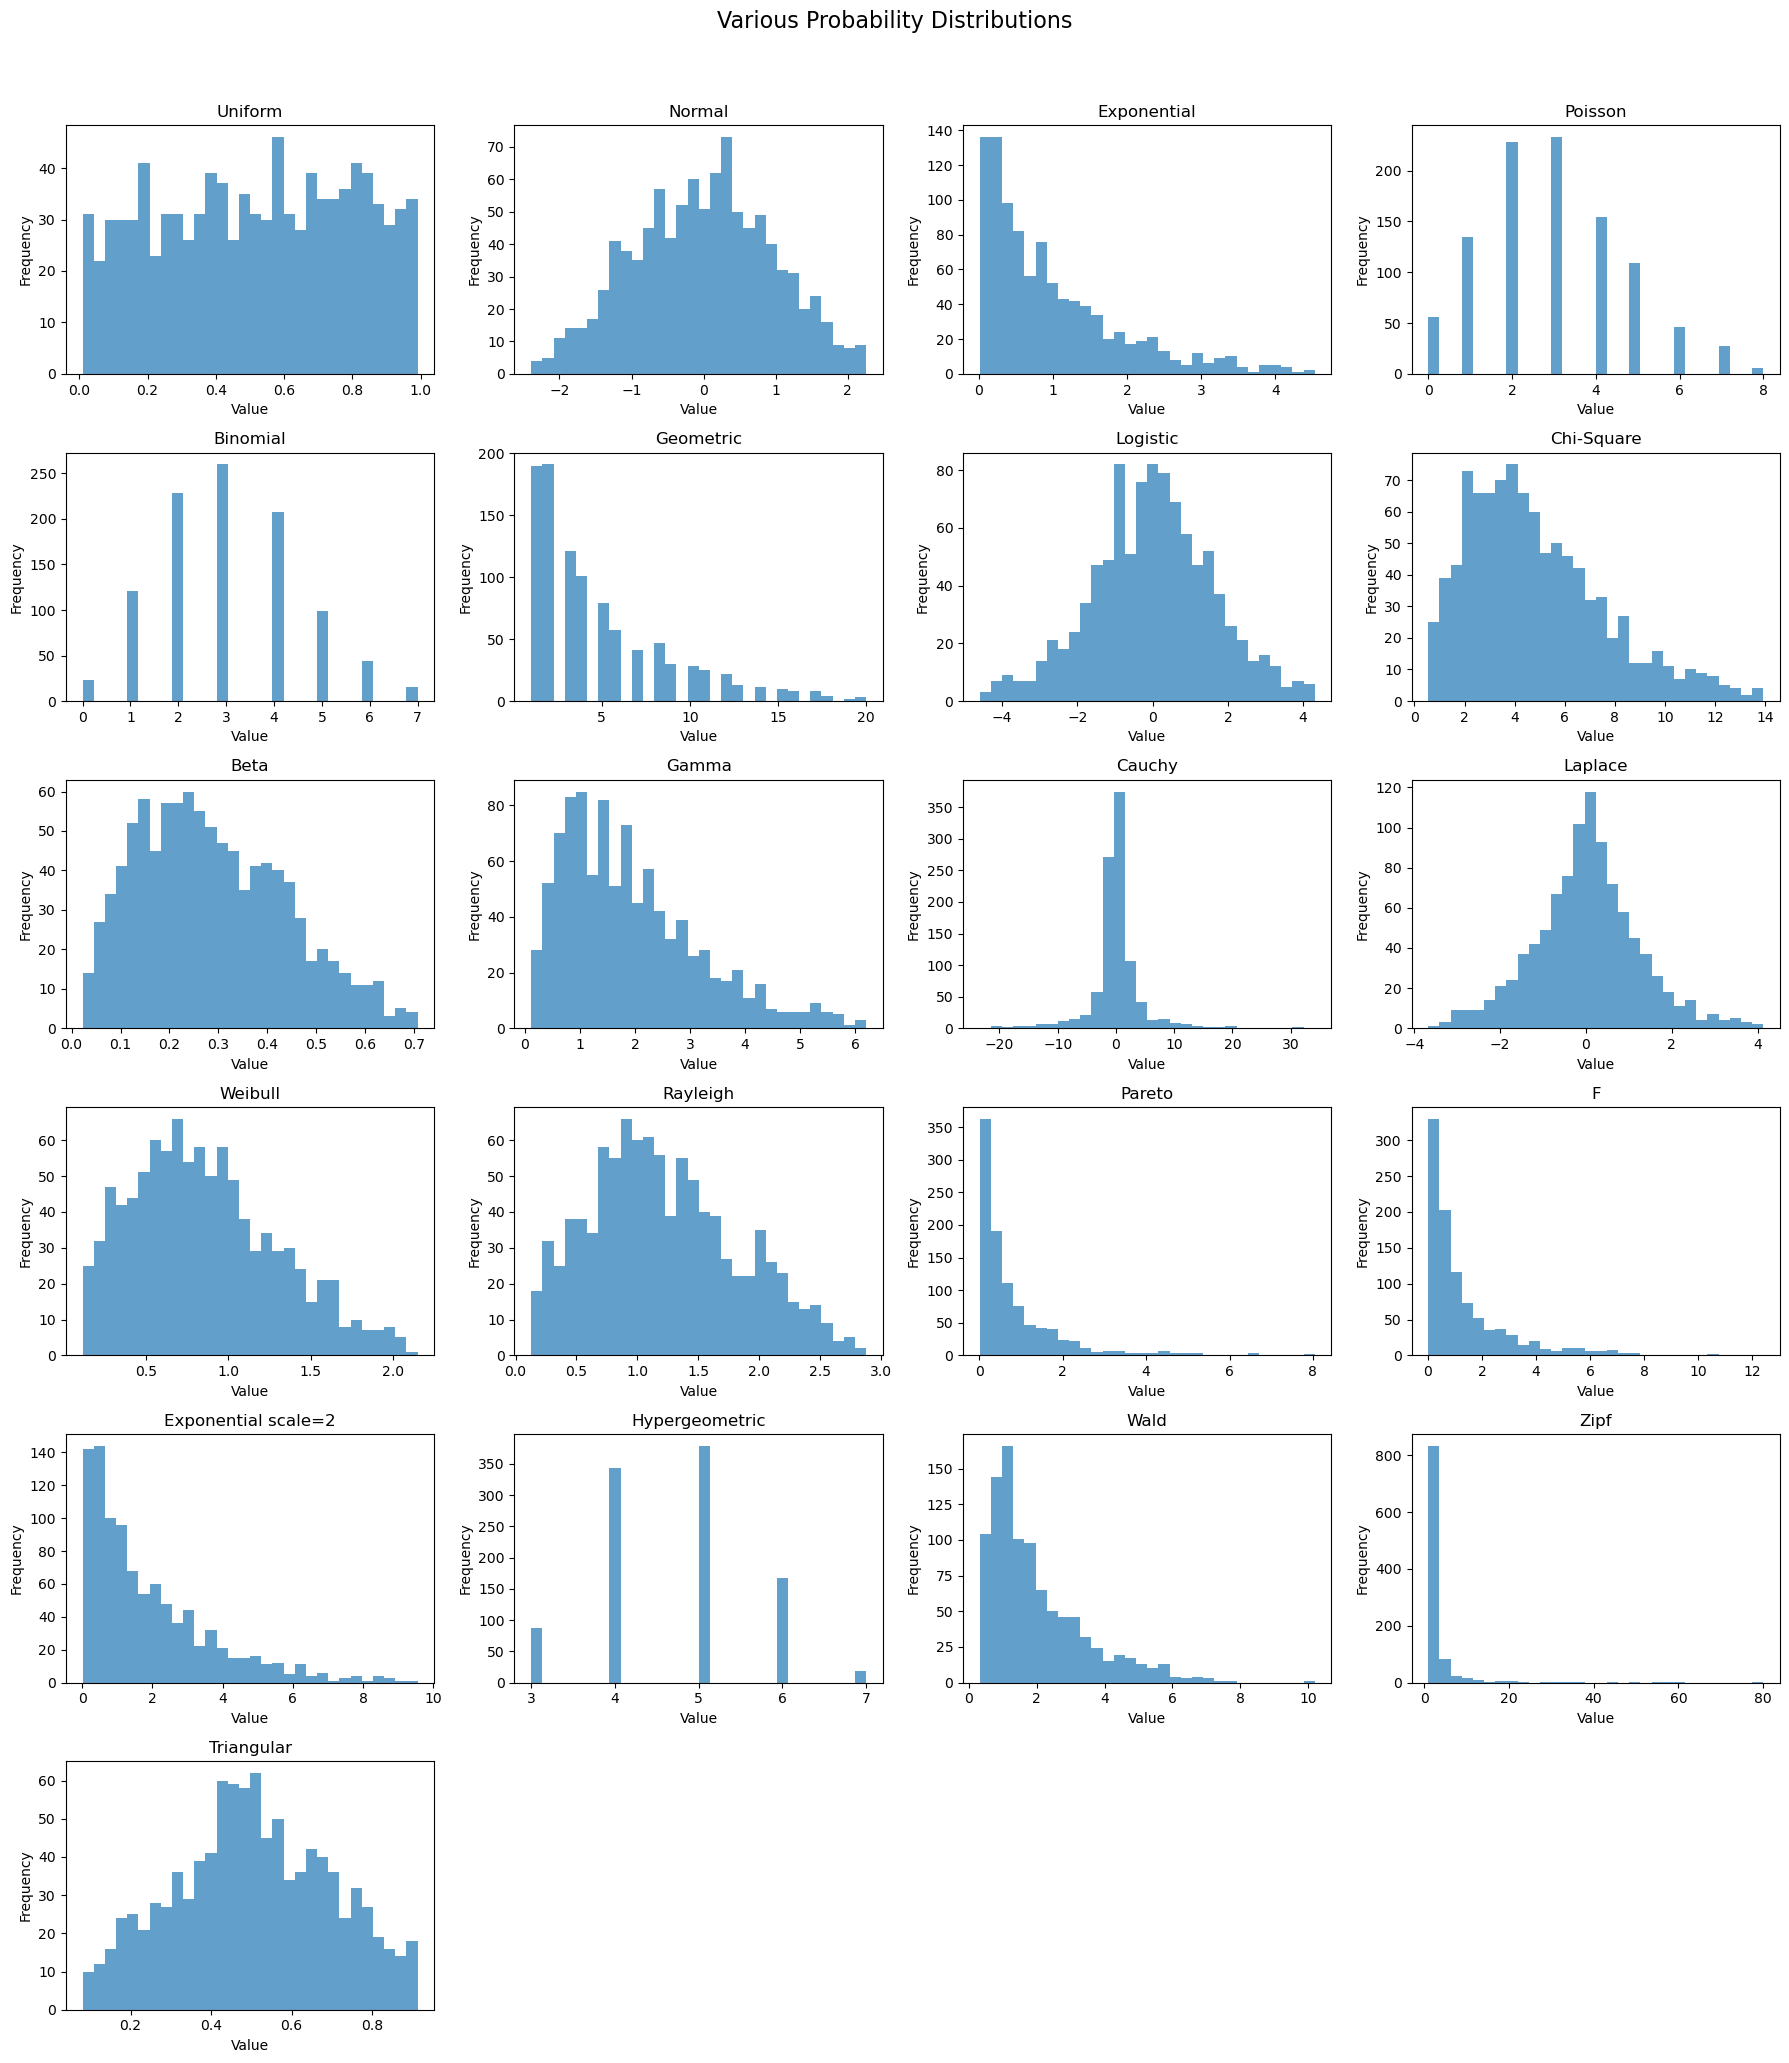

In [5]:
distributions = create_dist_synth(n_sample=1000, seed=0)
fig = plot_graph_distr(distributions, n_cols=4, bins=30, trim_heavy_tails=True)
plt.show()

## Normal

**Tipo:** contínua  
**Suporte:** $(-\infty,\infty)$  
**Média:** $\mu$  
**Variância:** $\sigma^2$  
**Uso típico:** erros, medidas e aproximações assintóticas.

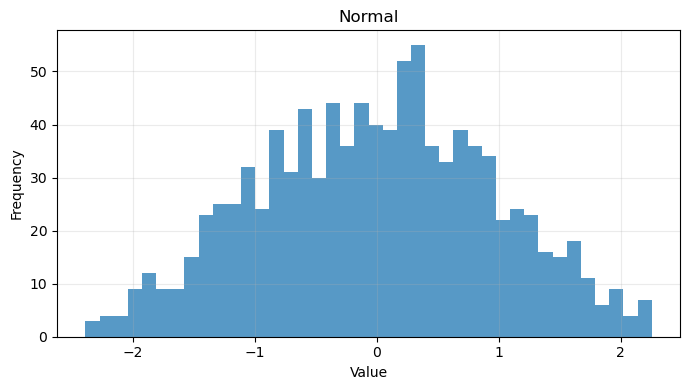

In [6]:
fig, ax = plot_single_distribution(distributions, name="Normal", bins=40, density=False)

## Binomial/Bernoulli

**Tipo:** discreta  
**Suporte:** $\{0,\ldots,n\}$  
**Média:** $np$  
**Variância:** $np(1-p)$  
**Uso típico:** número de sucessos em $n$ ensaios independentes.

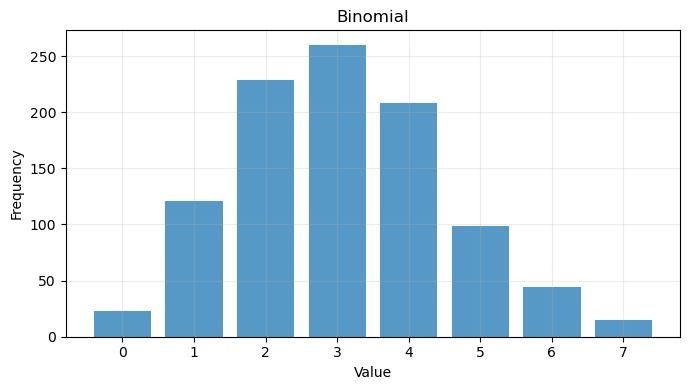

In [9]:
fig, ax = plot_single_distribution(distributions, name="Binomial", bins=40, density=False)

## Geométrica

**Tipo:** discreta  
**Suporte:** $\{1,2,\ldots\}$  
**Média:** $1/p$  
**Variância:** $(1-p)/p^2$  
**Uso típico:** número de tentativas até o primeiro sucesso.

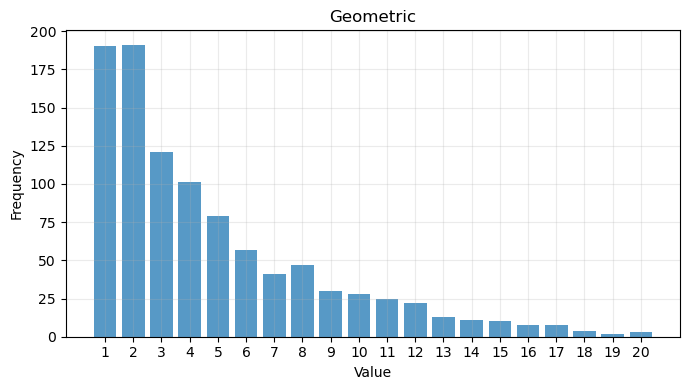

In [10]:
fig, ax = plot_single_distribution(distributions, name="Geometric", bins=40, density=False)

## Poisson

**Tipo:** discreta  
**Suporte:** $\{0,1,2,\ldots\}$  
**Média:** $\lambda$  
**Variância:** $\lambda$  
**Uso típico:** contagens raras em um intervalo fixo.

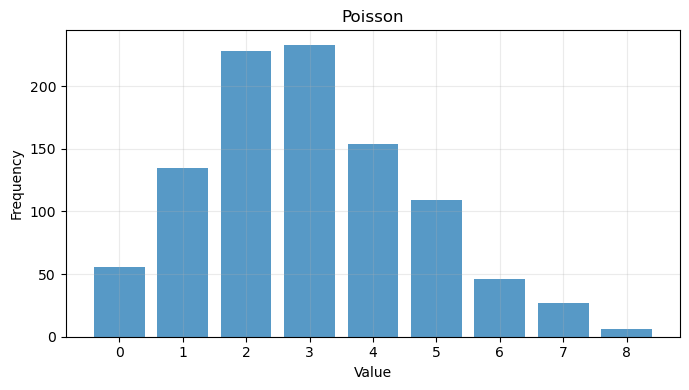

In [11]:
fig, ax = plot_single_distribution(distributions, name="Poisson", bins=40, density=False)

## Exponencial

**Tipo:** contínua  
**Suporte:** $[0,\infty)$  
**Média:** $1/\lambda$  
**Variância:** $1/\lambda^2$  
**Uso típico:** tempo de espera entre eventos de um processo de Poisson.

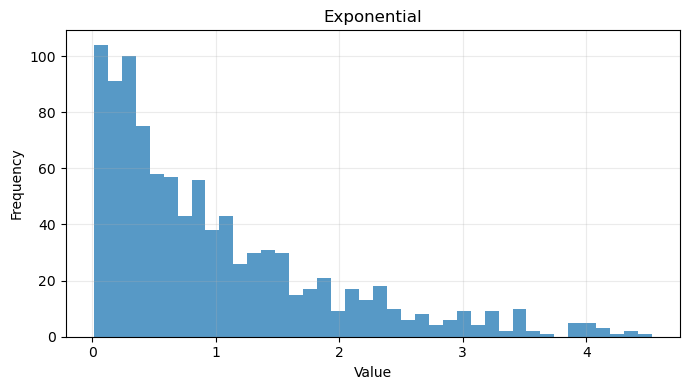

In [12]:
fig, ax = plot_single_distribution(distributions, name="Exponential", bins=40, density=False)

## Gamma

**Tipo:** contínua  
**Suporte:** $[0,\infty)$  
**Média:** $\alpha/\beta$  
**Variância:** $\alpha/\beta^2$  
**Uso típico:** soma de tempos exponenciais; modelos de duração.

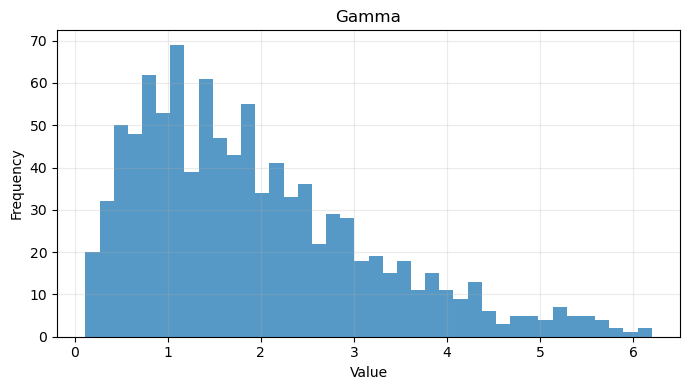

In [13]:
fig, ax = plot_single_distribution(distributions, name="Gamma", bins=40, density=False)

## Beta

**Tipo:** contínua  
**Suporte:** $[0,1]$  
**Média:** $\alpha/(\alpha+\beta)$  
**Variância:** $\alpha\beta/[(\alpha+\beta)^2(\alpha+\beta+1)]$  
**Uso típico:** proporções, probabilidades e priors bayesianos.

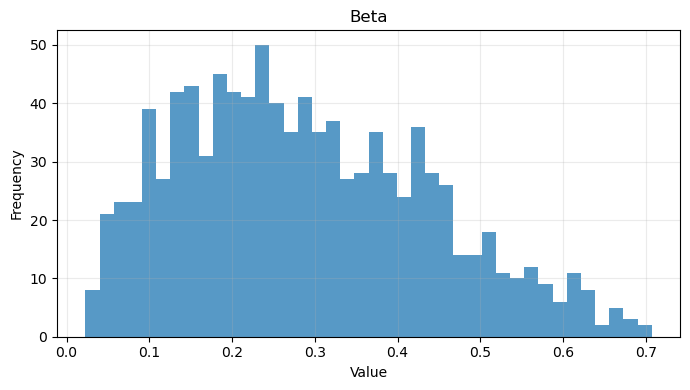

In [14]:
fig, ax = plot_single_distribution(distributions, name="Beta", bins=40, density=False)

## Uniforme

**Tipo:** contínua  
**Suporte:** $[a,b]$  
**Média:** $(a+b)/2$  
**Variância:** $(b-a)^2/12$  
**Uso típico:** ignorância equiprovável em um intervalo finito.am

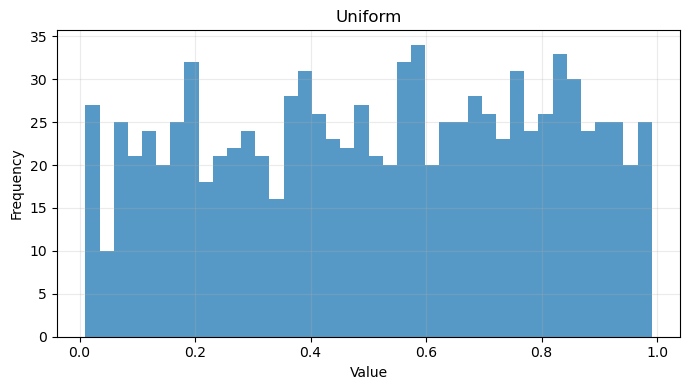

In [15]:
fig, ax = plot_single_distribution(distributions, name="Uniform", bins=40, density=False)